İŞİTME VERİLERİ ANALİZİ

İlk 5 gözlem:
   Yas Cinsiyet  Gurultu_Maruziyeti_Yili Tinnitus  Esik_500Hz  Esik_1000Hz  \
0   56    Erkek                     13.4      Var        20.7         27.8   
1   69    Erkek                     23.7      Var        23.0         22.9   
2   46    Kadın                     11.3      Var        12.0         24.7   
3   32    Kadın                      7.1      Yok         4.7         15.7   
4   60    Kadın                     18.9      Var        16.3         23.7   

   Esik_2000Hz  Esik_4000Hz  Konusma_Ayirt_Etme_Skoru  
0         29.6          NaN                      79.6  
1         25.0         53.5                      80.6  
2         37.8         34.4                      87.5  
3         12.1         29.1                      95.0  
4         26.8         46.2                      85.2  

Eksik değer sayıları:
Yas                         0
Cinsiyet                    0
Gurultu_Maruziyeti_Yili     5
Tinnitus                    0
Esik_500Hz   

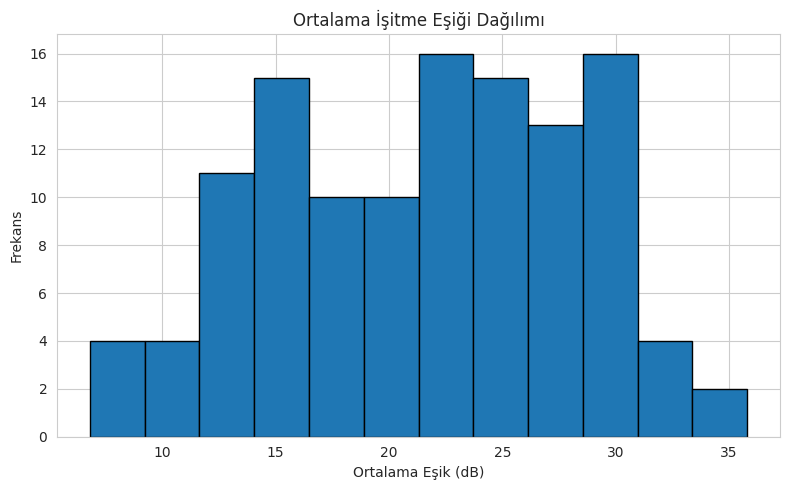

/tmp/ipykernel_17622/3559579380.py:155: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([grup_var, grup_yok], labels=["Var", "Yok"])


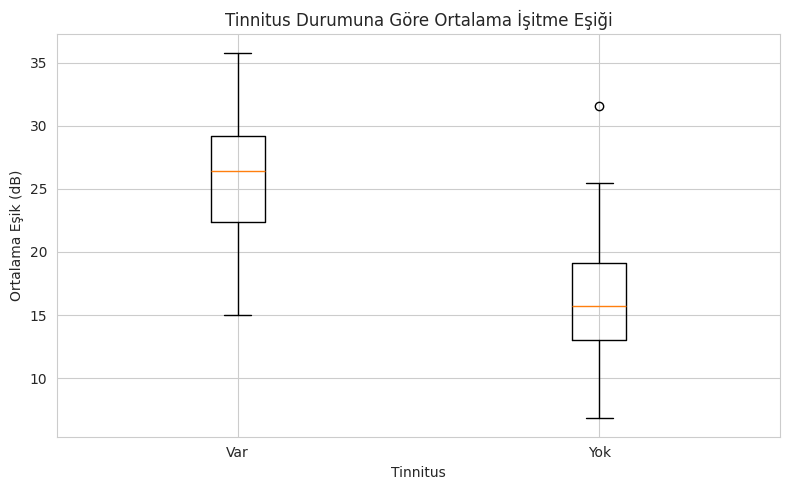

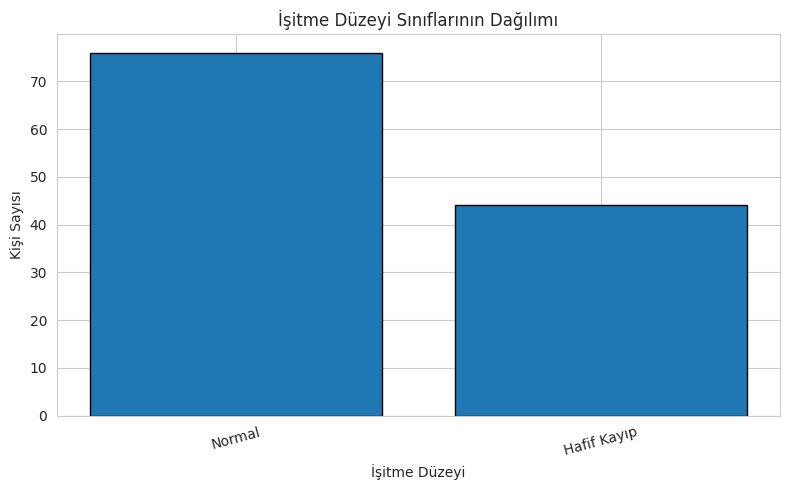

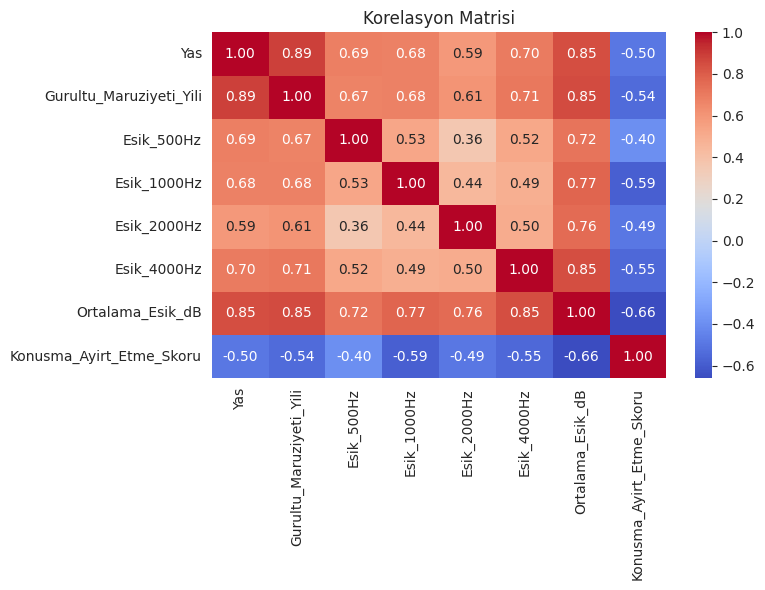


Doğrusal Regresyon Sonuçları
MAE: 2.25
R2: 0.78
Katsayılar:
 - Yas: 0.13
 - Gurultu_Maruziyeti_Yili: 0.38
 - Tinnitus_Kod: 4.65

İlk 5 kişinin işitme sınıfı (while döngüsü ile):
Kişi 1: Ortalama eşik=27.1 dB --> Hafif Kayıp
Kişi 2: Ortalama eşik=31.1 dB --> Hafif Kayıp
Kişi 3: Ortalama eşik=27.2 dB --> Hafif Kayıp
Kişi 4: Ortalama eşik=15.4 dB --> Normal
Kişi 5: Ortalama eşik=28.2 dB --> Hafif Kayıp

Frekans bazında ortalama eşikler (for döngüsü ile):
Esik_500Hz: 13.62 dB
Esik_1000Hz: 18.81 dB
Esik_2000Hz: 22.53 dB
Esik_4000Hz: 30.84 dB

Betik başarıyla tamamlandı.


In [1]:
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Grafiklerde Türkçe karakter sorunu yaşamamak için
plt.rcParams["font.family"] = "DejaVu Sans"

print("=" * 70)
print("İŞİTME VERİLERİ ANALİZİ")
print("=" * 70)

# -------------------------------------------------------------------
# 1) VERİ OLUŞTURMA
# -------------------------------------------------------------------
np.random.seed(42)
n = 120

yas = np.random.randint(18, 76, size=n)
cinsiyet = np.random.choice(["Kadın", "Erkek"], size=n)
maruziyet = np.clip((yas - 18) / 3 + np.random.normal(4, 3, size=n), 0, 30).round(1)

# Tinnitus (kulak çınlaması) olasılığı yaş ve gürültü maruziyeti ile artsın
tinnitus_olasilik = 1 / (1 + np.exp(-(-3 + 0.04 * yas + 0.09 * maruziyet)))
tinnitus = np.where(np.random.rand(n) < tinnitus_olasilik, "Var", "Yok")

# Frekanslara göre işitme eşikleri (dB)
esik_500 = np.clip(5 + 0.12 * yas + 0.18 * maruziyet + (tinnitus == "Var") * 2 + np.random.normal(0, 4, n), 0, 70)
esik_1000 = np.clip(7 + 0.14 * yas + 0.22 * maruziyet + (tinnitus == "Var") * 3 + np.random.normal(0, 5, n), 0, 75)
esik_2000 = np.clip(8 + 0.18 * yas + 0.28 * maruziyet + (tinnitus == "Var") * 4 + np.random.normal(0, 6, n), 0, 85)
esik_4000 = np.clip(10 + 0.25 * yas + 0.42 * maruziyet + (tinnitus == "Var") * 6 + np.random.normal(0, 7, n), 0, 95)

konusma_skoru = np.clip(
    100 - (esik_500 + esik_1000 + esik_2000 + esik_4000) / 8 - (tinnitus == "Var") * 4 + np.random.normal(0, 4, n),
    35,
    100
)

df = pd.DataFrame({
    "Yas": yas,
    "Cinsiyet": cinsiyet,
    "Gurultu_Maruziyeti_Yili": maruziyet,
    "Tinnitus": tinnitus,
    "Esik_500Hz": esik_500.round(1),
    "Esik_1000Hz": esik_1000.round(1),
    "Esik_2000Hz": esik_2000.round(1),
    "Esik_4000Hz": esik_4000.round(1),
    "Konusma_Ayirt_Etme_Skoru": konusma_skoru.round(1)
})

# Bazı eksik değerler ekleyelim ki veri temizleme de gösterilebilsin
eksik_indeks_1 = np.random.choice(df.index, size=5, replace=False)
eksik_indeks_2 = np.random.choice(df.index, size=4, replace=False)
eksik_indeks_3 = np.random.choice(df.index, size=4, replace=False)

df.loc[eksik_indeks_1, "Gurultu_Maruziyeti_Yili"] = np.nan
df.loc[eksik_indeks_2, "Esik_4000Hz"] = np.nan
df.loc[eksik_indeks_3, "Konusma_Ayirt_Etme_Skoru"] = np.nan

print("\nİlk 5 gözlem:")
print(df.head())

# -------------------------------------------------------------------
# 2) VERİ TEMİZLEME VE DÖNÜŞTÜRME
# -------------------------------------------------------------------
print("\nEksik değer sayıları:")
print(df.isnull().sum())

# Sayısal eksikleri medyan ile doldurma
sayisal_sutunlar = df.select_dtypes(include=np.number).columns
for sutun in sayisal_sutunlar:
    df[sutun] = df[sutun].fillna(df[sutun].median())

# İşitme ortalaması (PTA benzeri)
df["Ortalama_Esik_dB"] = df[["Esik_500Hz", "Esik_1000Hz", "Esik_2000Hz", "Esik_4000Hz"]].mean(axis=1).round(1)

# Yaş grubu oluşturma
df["Yas_Grubu"] = pd.cut(
    df["Yas"],
    bins=[17, 30, 45, 60, 80],
    labels=["18-30", "31-45", "46-60", "61+"]
)

def isitme_duzeyi_belirle(ortalama_esik):
    if ortalama_esik <= 25:
        return "Normal"
    elif ortalama_esik <= 40:
        return "Hafif Kayıp"
    elif ortalama_esik <= 55:
        return "Orta Kayıp"
    else:
        return "İleri Kayıp"

df["Isitme_Duzeyi"] = df["Ortalama_Esik_dB"].apply(isitme_duzeyi_belirle)

print("\nTemizlenmiş veri özeti:")
print(df.describe())

print("\nİşitme düzeyi dağılımı:")
print(df["Isitme_Duzeyi"].value_counts())

# -------------------------------------------------------------------
# 3) ÇARPIKLIK / BASIKLIK / AYKIRI DEĞER KONTROLÜ
# -------------------------------------------------------------------
print("\nÇarpıklık ve basıklık değerleri:")
for sutun in ["Esik_500Hz", "Esik_1000Hz", "Esik_2000Hz", "Esik_4000Hz", "Ortalama_Esik_dB"]:
    print(
        f"{sutun}: Çarpıklık={df[sutun].skew():.2f}, Basıklık={df[sutun].kurt():.2f}"
    )

print("\nIQR yöntemine göre aykırı değer sayıları:")
for sutun in ["Esik_500Hz", "Esik_1000Hz", "Esik_2000Hz", "Esik_4000Hz", "Ortalama_Esik_dB"]:
    q1 = df[sutun].quantile(0.25)
    q3 = df[sutun].quantile(0.75)
    iqr = q3 - q1
    aykirilar = df[(df[sutun] < q1 - 1.5 * iqr) | (df[sutun] > q3 + 1.5 * iqr)]
    print(f"{sutun}: {aykirilar.shape[0]} aykırı gözlem")

# -------------------------------------------------------------------
# 4) GRUPLAMA VE ÖZET İSTATİSTİKLER
# -------------------------------------------------------------------
print("\nYaş grubuna göre ortalama işitme eşiği:")
print(df.groupby("Yas_Grubu", observed=False)["Ortalama_Esik_dB"].mean().round(2))

print("\nTinnitus durumuna göre konuşma ayırt etme skoru ortalaması:")
print(df.groupby("Tinnitus")["Konusma_Ayirt_Etme_Skoru"].mean().round(2))

# -------------------------------------------------------------------
# 5) GÖRSELLEŞTİRME
# -------------------------------------------------------------------
sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))
plt.hist(df["Ortalama_Esik_dB"], bins=12, edgecolor="black")
plt.title("Ortalama İşitme Eşiği Dağılımı")
plt.xlabel("Ortalama Eşik (dB)")
plt.ylabel("Frekans")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
grup_var = df[df["Tinnitus"] == "Var"]["Ortalama_Esik_dB"]
grup_yok = df[df["Tinnitus"] == "Yok"]["Ortalama_Esik_dB"]
plt.boxplot([grup_var, grup_yok], labels=["Var", "Yok"])
plt.title("Tinnitus Durumuna Göre Ortalama İşitme Eşiği")
plt.xlabel("Tinnitus")
plt.ylabel("Ortalama Eşik (dB)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sayim = df["Isitme_Duzeyi"].value_counts()
plt.bar(sayim.index, sayim.values, edgecolor="black")
plt.title("İşitme Düzeyi Sınıflarının Dağılımı")
plt.xlabel("İşitme Düzeyi")
plt.ylabel("Kişi Sayısı")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
korelasyon_df = df[[
    "Yas",
    "Gurultu_Maruziyeti_Yili",
    "Esik_500Hz",
    "Esik_1000Hz",
    "Esik_2000Hz",
    "Esik_4000Hz",
    "Ortalama_Esik_dB",
    "Konusma_Ayirt_Etme_Skoru"
]]
sns.heatmap(korelasyon_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasyon Matrisi")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 6) DOĞRUSAL REGRESYON
# -------------------------------------------------------------------
# Tinnitus değişkenini sayısal hale getirelim
df["Tinnitus_Kod"] = np.where(df["Tinnitus"] == "Var", 1, 0)

X = df[["Yas", "Gurultu_Maruziyeti_Yili", "Tinnitus_Kod"]]
y = df["Ortalama_Esik_dB"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_tahmin = model.predict(X_test)

mae = mean_absolute_error(y_test, y_tahmin)
r2 = r2_score(y_test, y_tahmin)

print("\nDoğrusal Regresyon Sonuçları")
print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.2f}")
print("Katsayılar:")
for degisken, katsayi in zip(X.columns, model.coef_):
    print(f" - {degisken}: {katsayi:.2f}")

# -------------------------------------------------------------------
# 7) TEMEL PYTHON YAPILARI: FONKSİYON, FOR, IF-ELIF-ELSE, WHILE
# -------------------------------------------------------------------
print("\nİlk 5 kişinin işitme sınıfı (while döngüsü ile):")
i = 0
while i < 5:
    esik = df.loc[i, "Ortalama_Esik_dB"]
    print(f"Kişi {i + 1}: Ortalama eşik={esik} dB --> {isitme_duzeyi_belirle(esik)}")
    i += 1

print("\nFrekans bazında ortalama eşikler (for döngüsü ile):")
for sutun in ["Esik_500Hz", "Esik_1000Hz", "Esik_2000Hz", "Esik_4000Hz"]:
    print(f"{sutun}: {df[sutun].mean():.2f} dB")

print("\nBetik başarıyla tamamlandı.")
